In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from arch.bootstrap import StationaryBootstrap

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
# !pip install --upgrade pip
# !pip install linearmodels
# !pip install xlsxwriter

In [3]:
np.random.seed(42)

In [4]:
from utils import *

In [5]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results


def ols_new_west(data, x_vars, target):
    subset = data.dropna(subset=[target] + x_vars)
    
    formula = f"{target} ~ {' + '.join(x_vars)}"
    
    model = smf.ols(formula, data=subset)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    return results


def fit_one_factor(df, sentiment, return_names, control_variables=None):
    features_res = {}
    
    for target in return_names:
#         if 'growth_MB' in sentiment:
        if control_variables is not None:
            results = ols_new_west(df, [sentiment] + control_variables, target)
        else:
            results = ols_new_west(df, [sentiment], target)
        
        features_res[target] = {}
        features_res[target]['model'] = results
        features_res[target]['coef'] = round(results.params[sentiment], 3)
        features_res[target]['t'] = round(results.tvalues[sentiment], 3)
        features_res[target]['r2_adj'] = round(100*results.rsquared_adj, 3)
        
        pval = round(results.pvalues[sentiment], 3)
        
        features_res[target]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[target]['sgnf'] = sgnf
        
    table_res = pd.DataFrame(features_res).T.drop('model', axis=1)
    table_res['coef'] = table_res['coef'].astype(str) + table_res['sgnf']
    table_res = table_res[['coef', 't', 'r2_adj', 'pval']]
        
    return features_res, table_res

## Data

In [6]:
sent_df = pd.read_csv("frankel_sentiments_full_sample_with_growth.tsv.gz", sep='\t', compression='gzip')

sent_df['year'] = sent_df['FILING_DATE'].apply(lambda x: str(x)[:4])
sent_df['year_month'] = sent_df['FILING_DATE'].astype(str).str[:6]

sent_df = sent_df[sent_df['year'] >= '2003'].reset_index(drop=True)

In [8]:
# sent_df = sent_df[(sent_df['industry_code'] != 'Money') & (sent_df['industry_code'] != 'Utils')].copy().reset_index(drop=True)

In [9]:
sent_10q = pd.read_csv("growth_10q_llama_mb.tsv.gz", sep='\t', compression='gzip')

sent_10q['year'] = sent_10q['FILING_DATE'].apply(lambda x: str(x)[:4])
sent_10q['year_month'] = sent_10q['FILING_DATE'].astype(str).str[:6]

new_cols = []
for col in sent_10q.columns:
    if 'growth' in col:
        new_cols.append(col.replace('_10q', ''))
    else:
        new_cols.append(col)
sent_10q.columns = new_cols

In [10]:
# sent_10q = sent_10q[(sent_10q['industry_code'] != 'Money') & (sent_10q['industry_code'] != 'Utils')].copy().reset_index(drop=True)

In [11]:
sent_df.columns

Index(['gvkey', 'datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco',
       'permno', 'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT',
       'turnover', 'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg',
       'tone', 'tone_posharvard', 'tone_negharvard', 'tone_harvard',
       'rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'year', 'ln_mve',
       'factorpred_car01', 'ACC_NUM', 'CIK', 'FILING_DATE', 'positive_general',
       'negative_general', 'polarity_general', 'positive_revenue',
       'negative_revenue', 'polarity_revenue', 'positive_profit',
       'negative_profit', 'polarity_profit', 'positive_strategic_risk',
       'negative_strategic_risk', 'polarity_strategic_risk',
       'positive_operational_risk', 'negative_operational_risk',
       'polarity_operational_risk', 'positive_financial_risk',
       'negative_financial_risk', 'polarity_financial_risk',
       'positive_reputation_risk', 'negative_reputation_risk',
       'polarity_reputation_ris

In [181]:
sent_df[['positive_growth_llama', 'negative_growth_llama', 'positive_general', 'negative_general']].mean()

,positive_growth_llama,negative_growth_llama,positive_general,negative_general
industry_code,,,,
BusEq,0.337915,0.144022,0.213997,0.110926
Chems,0.391758,0.104892,0.240642,0.095855
Durbl,0.373080,0.115503,0.230594,0.098668
Enrgy,0.367524,0.134313,0.213209,0.113541
Hlth,0.324826,0.180535,0.177270,0.142597
Manuf,0.380166,0.109358,0.236861,0.097573
Money,0.422152,0.121417,0.257469,0.080831
NoDur,0.379088,0.124001,0.237975,0.094158
Shops,0.391147,0.120977,0.234639,0.097453


In [171]:
sent_df[['industry_code', 'industry_name']].drop_duplicates()

,industry_code,industry_name
0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of..."
17,BusEq,"Business Equipment -- Computers, Software, and..."
24,Hlth,"Healthcare, Medical Equipment, and Drugs"
30,NaN,NaN
73,Utils,Utilities
124,Shops,"Wholesale, Retail, and Some Services (Laundrie..."
167,Money,Finance
183,Chems,Chemicals and Allied Products
257,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile..."
280,Durbl,"Consumer Durables -- Cars, TVs, Furniture, Hou..."


In [178]:
sent_df[['positive_general', 'positive_growth_llama']].corr()

,positive_general,positive_growth_llama
positive_general,1.000000,0.560564
positive_growth_llama,0.560564,1.000000


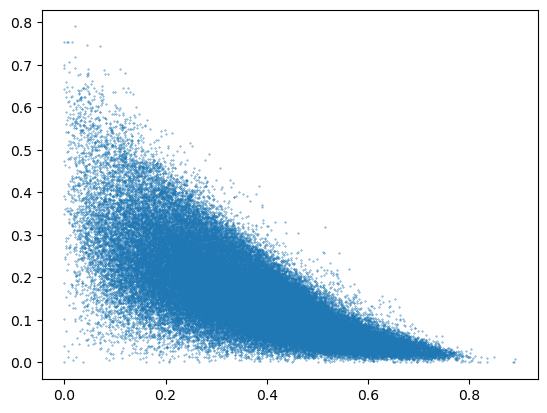

In [183]:
plt.scatter(sent_df['positive_growth_llama'], sent_df['negative_growth_llama'], s=0.1)

In [184]:
sent_df['range_growth_llama'] = sent_df['positive_growth_llama'] + sent_df['negative_growth_llama']

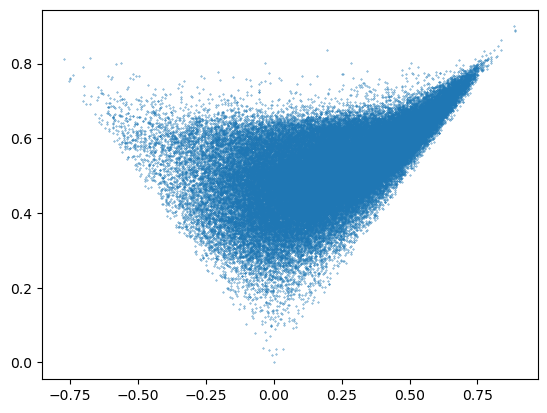

In [186]:
plt.scatter(sent_df['polarity_growth_llama'], sent_df['range_growth_llama'], s=0.1)

In [187]:
ts = sent_df.groupby('year_month').agg(
    {'range_growth_llama': 'mean',
     'polarity_growth_llama': 'mean',
    }
)

ts = ts.reset_index()

In [188]:
ts

,year_month,range_growth_llama,polarity_growth_llama
0,200301,0.512557,0.166882
1,200302,0.510675,0.204753
2,200303,0.521100,0.196002
3,200304,0.510565,0.152968
4,200305,0.499632,0.168637
...,...,...,...
247,202308,0.534122,0.240571
248,202309,0.560462,0.194823
249,202310,0.564870,0.127893
250,202311,0.548567,0.286829


In [13]:
# ts['year_month'] = pd.to_datetime(ts['year_month'], format='%Y%m')

# ts = ts.sort_values('year_month')

# window_size = 4

# ts['range_growth_llama_4m'] = ts['range_growth_llama'].rolling(window=window_size, center=False).mean()
# ts['polarity_growth_llama_4m'] = ts['polarity_growth_llama'].rolling(window=window_size, center=False).mean()


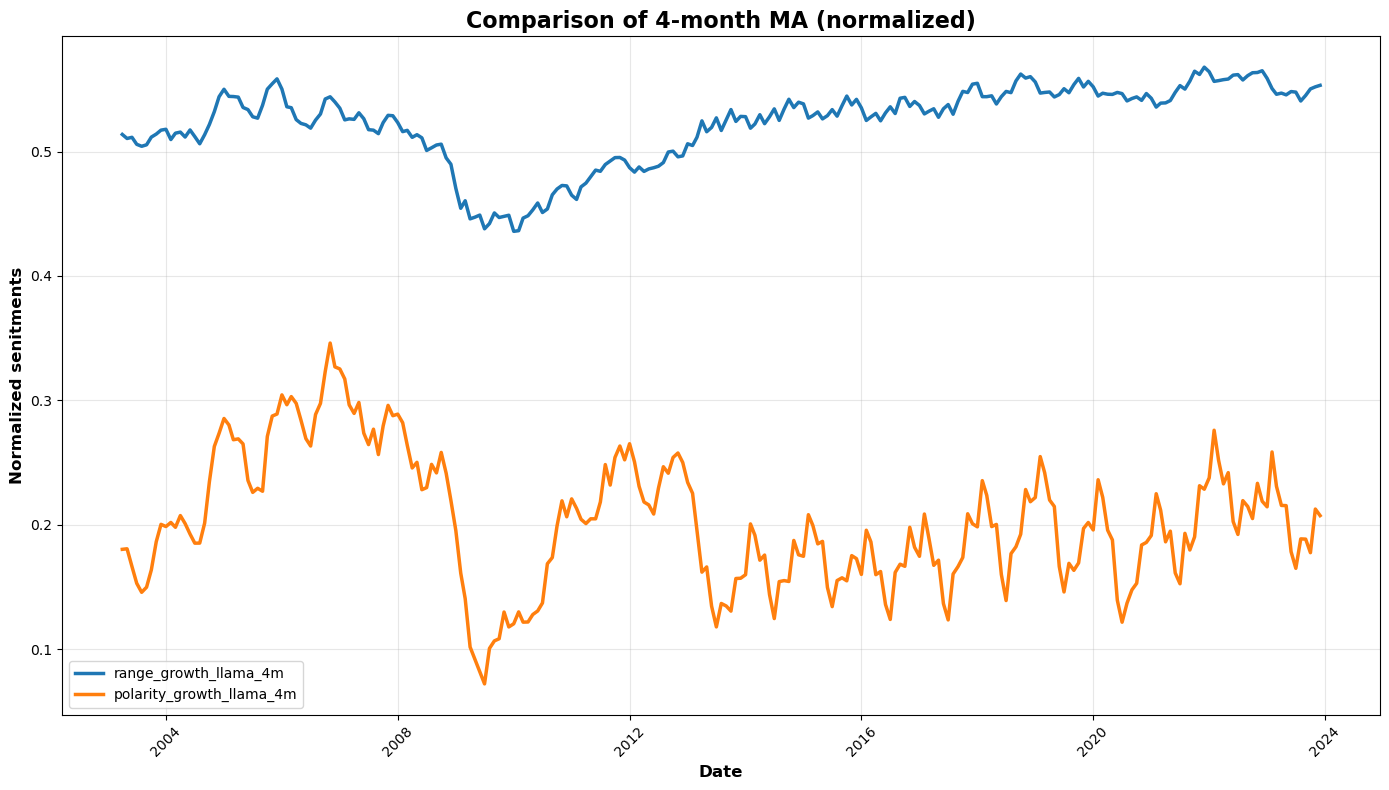

In [192]:
fig2, ax2 = plt.subplots(figsize=(14, 8))

ax2.plot(ts['year_month'], ts['range_growth_llama_4m'], 
         label='range_growth_llama_4m', 
         linewidth=2.5)

ax2.plot(ts['year_month'], ts['polarity_growth_llama_4m'], 
         label='polarity_growth_llama_4m', 
         linewidth=2.5)

ax2.set_title('Comparison of 4-month MA (normalized)', 
              fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Normalized senitments', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
sentiment_cols = [
    'positive_growth_llama', 'negative_growth_llama', 'polarity_growth_llama',
    'polarity_financial_risk', 'polarity_operational_risk', 'polarity_reputation_risk',
    'polarity_strategic_risk', 'polarity_compliance_risk'
]

In [75]:
sent_df[sentiment_cols].corr()

,positive_growth_llama,negative_growth_llama,polarity_growth_llama,polarity_financial_risk,polarity_operational_risk,polarity_reputation_risk,polarity_strategic_risk,polarity_compliance_risk
positive_growth_llama,1.000000,-0.749361,0.959623,0.397527,0.386196,0.251537,0.391923,0.241668
negative_growth_llama,-0.749361,1.000000,-0.905363,-0.412068,-0.320379,-0.219807,-0.341143,-0.198877
polarity_growth_llama,0.959623,-0.905363,1.000000,0.428606,0.385228,0.255248,0.397183,0.240437
polarity_financial_risk,0.397527,-0.412068,0.428606,1.000000,0.530638,0.393800,0.533295,0.421133
polarity_operational_risk,0.386196,-0.320379,0.385228,0.530638,1.000000,0.573742,0.754057,0.624896
polarity_reputation_risk,0.251537,-0.219807,0.255248,0.393800,0.573742,1.000000,0.602809,0.596218
polarity_strategic_risk,0.391923,-0.341143,0.397183,0.533295,0.754057,0.602809,1.000000,0.597090
polarity_compliance_risk,0.241668,-0.198877,0.240437,0.421133,0.624896,0.596218,0.597090,1.000000


In [70]:
# sent = pd.concat([
#     sent_df[['year', 'year_month'] + sentiment_cols],
#     sent_10q[['year', 'year_month'] + sentiment_cols]
# ], axis=0, ignore_index=True)

In [16]:
assert sent.shape[0] == sent_10q.shape[0] + sent_df.shape[0]

In [17]:
# sent.to_csv("growth_10q_10k_by_year.tsv.gz", sep='\t', compression='gzip', index=False)

In [18]:
sent['month'] = sent['year_month'].astype(str).str[4:6]

In [15]:
# sent.groupby('month').size().plot()
# plt.grid()
# plt.ylim(0, 50000)
# plt.show()

In [19]:
ts_df = sent.groupby('year_month').agg(
    {'negative_growth_MB': 'mean',
     'positive_growth_MB': 'mean',
     'polarity_growth_MB': 'mean',
     'negative_growth_llama': 'mean',
     'positive_growth_llama': 'mean',
     'polarity_growth_llama': 'mean',
    }
)

ts_df = ts_df.reset_index()

In [20]:
ts_df

,year_month,negative_growth_MB,positive_growth_MB,polarity_growth_MB,negative_growth_llama,positive_growth_llama,polarity_growth_llama
0,200301,0.229378,0.593717,0.364339,0.155733,0.335884,0.180151
1,200302,0.234728,0.592324,0.357597,0.147836,0.349090,0.201254
2,200303,0.239105,0.624781,0.385675,0.161801,0.357759,0.195958
3,200304,0.221376,0.604304,0.382927,0.157287,0.341306,0.184018
4,200305,0.233942,0.570668,0.336725,0.140806,0.352214,0.211408
...,...,...,...,...,...,...,...
247,202308,0.252314,0.455933,0.203619,0.113721,0.346073,0.232352
248,202309,0.247981,0.520977,0.272996,0.156958,0.357123,0.200165
249,202310,0.258386,0.460994,0.202608,0.132887,0.340523,0.207635
250,202311,0.256814,0.451805,0.194990,0.114196,0.351187,0.236991


In [21]:
jlmz_sent = pd.read_excel('JLMZ_MS_Index2017.xlsx')

jlmz_sent['year_month'] = jlmz_sent['date'].str.replace('-', '')
jlmz_sent.drop('date', axis=1, inplace=True)
jlmz_sent = jlmz_sent.rename(columns={'Manager Sentiment Index': 'msi'})

In [22]:
df = jlmz_sent.merge(ts_df, on='year_month', how='right')

In [23]:
df[['msi', 'polarity_growth_MB', 'polarity_growth_llama']].corr()

,msi,polarity_growth_MB,polarity_growth_llama
msi,1.000000,-0.106267,0.274021
polarity_growth_MB,-0.106267,1.000000,0.186757
polarity_growth_llama,0.274021,0.186757,1.000000


In [25]:
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y%m')

df = df.sort_values('year_month')

window_size = 4

df['msi_ma_4m'] = df['msi'].rolling(window=window_size, center=False).mean()
df['negative_growth_MB_ma_4m'] = df['negative_growth_MB'].rolling(window=window_size, center=False).mean()
df['polarity_growth_MB_ma_4m'] = df['polarity_growth_MB'].rolling(window=window_size, center=False).mean()

df['negative_growth_llama_ma_4m'] = df['negative_growth_llama'].rolling(window=window_size, center=False).mean()
df['positive_growth_llama_ma_4m'] = df['positive_growth_llama'].rolling(window=window_size, center=False).mean()
df['polarity_growth_llama_ma_4m'] = df['polarity_growth_llama'].rolling(window=window_size, center=False).mean()

In [22]:
df[df['year_month'].between('2003-01-01', '2014-12-31')]['msi'].describe()

count    144.000000
mean       0.016000
std        1.046498
min       -4.146000
25%       -0.403500
50%        0.153500
75%        0.717250
max        1.966000
Name: msi, dtype: float64

In [26]:
scaler = StandardScaler()
data_to_normalize = df[['msi_ma_4m', 'negative_growth_llama_ma_4m', 'positive_growth_llama_ma_4m', 'polarity_growth_llama_ma_4m']].dropna()
normalized_data = scaler.fit_transform(data_to_normalize)


normalized_df = pd.DataFrame(normalized_data, 
                            columns=['msi_ma_4m_norm', 'negative_growth_llama_ma_4m_norm', 
                                     'positive_growth_llama_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm'],
                            index=data_to_normalize.index)

dates_for_normalized = df.loc[normalized_df.index, 'year_month']
normalized_df['year_month'] = dates_for_normalized

# normalized_df['sentiment_growth_MB_ma_4m_norm'] = np.where(
#     normalized_df['year_month'] <= pd.to_datetime('2011-01-01'),
#     normalized_df['negative_growth_MB_ma_4m_norm'],
#     normalized_df['polarity_growth_MB_ma_4m_norm'])

normalized_df = normalized_df.reset_index(drop=True)

In [27]:
# normalized_df[['msi_ma_4m_norm', 'polarity_growth_MB_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm']].corr()

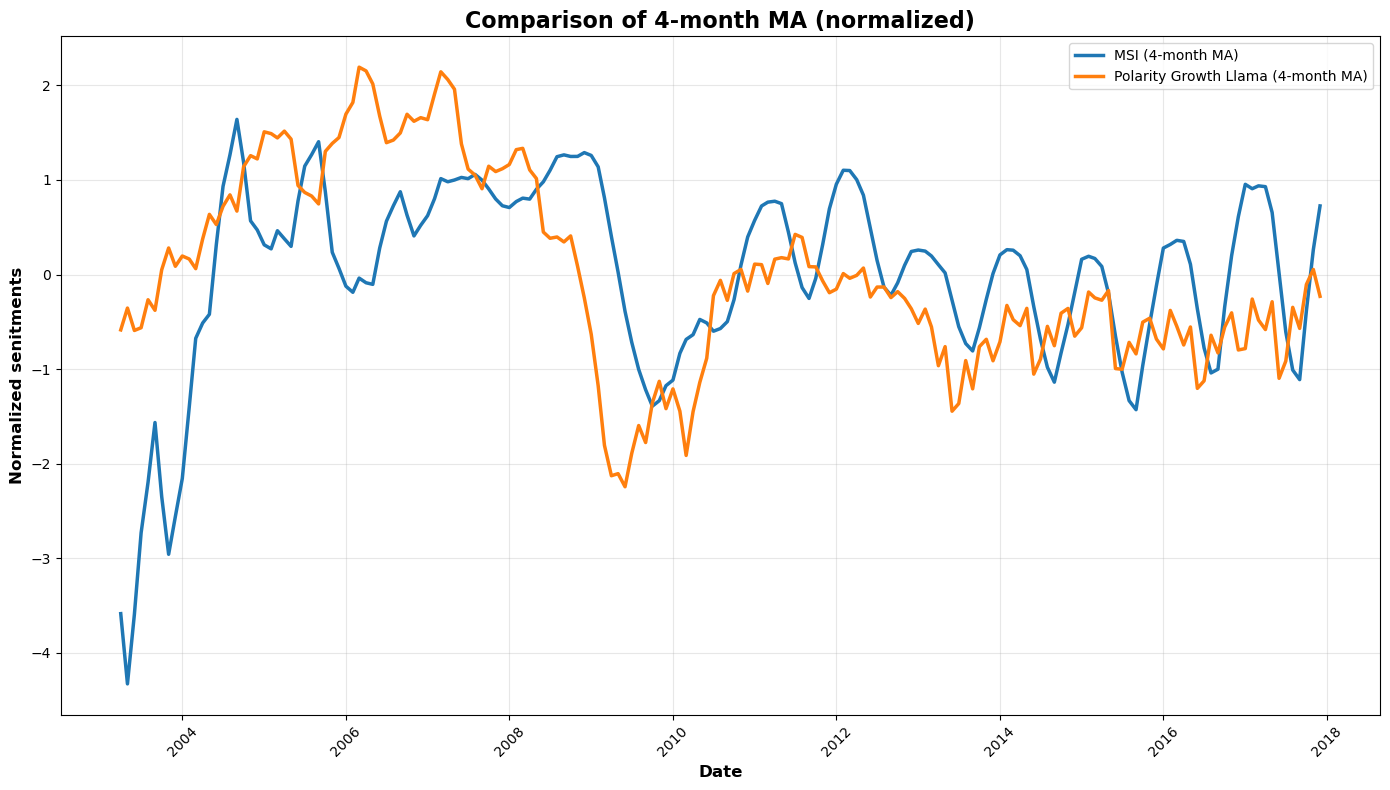

In [28]:
fig2, ax2 = plt.subplots(figsize=(14, 8))

ax2.plot(dates_for_normalized, normalized_df['msi_ma_4m_norm'], 
         label='MSI (4-month MA)', 
         linewidth=2.5)

# ax2.plot(dates_for_normalized, normalized_df['polarity_growth_MB_ma_4m_norm'], 
#          label='Polarity Growth MB (4-month MA)', 
#          linewidth=2.5)

ax2.plot(dates_for_normalized, normalized_df['polarity_growth_llama_ma_4m_norm'], 
         label='Polarity Growth Llama (4-month MA)', 
         linewidth=2.5)

ax2.set_title('Comparison of 4-month MA (normalized)', 
              fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Normalized senitments', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

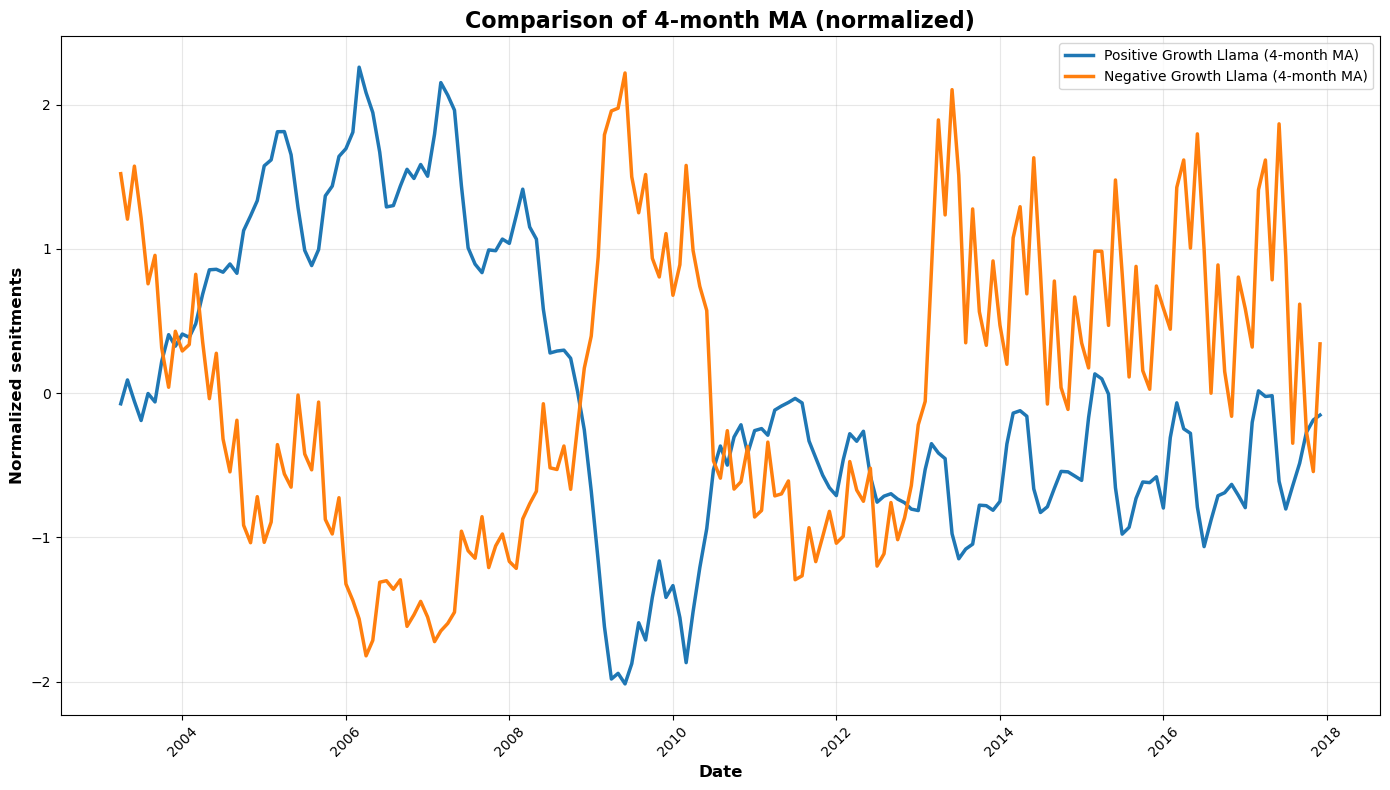

In [29]:
fig2, ax2 = plt.subplots(figsize=(14, 8))

ax2.plot(dates_for_normalized, normalized_df['positive_growth_llama_ma_4m_norm'], 
         label='Positive Growth Llama (4-month MA)', 
         linewidth=2.5)

ax2.plot(dates_for_normalized, normalized_df['negative_growth_llama_ma_4m_norm'], 
         label='Negative Growth Llama (4-month MA)', 
         linewidth=2.5)

ax2.set_title('Comparison of 4-month MA (normalized)', 
              fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Normalized senitments', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model

Rmt+1 (the monthly return on the S&P 500 index in excess of the risk-free rate

In [30]:
predictor_data = pd.read_excel('PredictorData2024.xlsx')

In [31]:
predictor_data.tail()

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx
1843,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898
1844,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707
1845,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523
1846,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016
1847,202412,5881.63,74.832255,210.170000,0.183056,0.0427,0.0520,0.0580,0.0439,-0.004614,0.0037,0.000355,-0.015408,-0.019354,0.001643,NaN,-0.023445,-0.024621


In [32]:
# plt.plot(predictor_data['yyyymm'], predictor_data['Index'])

In [33]:
data = predictor_data[predictor_data['yyyymm'] > 200211].copy().reset_index(drop=True)
data['year_month'] = pd.to_datetime(data['yyyymm'], format='%Y%m')

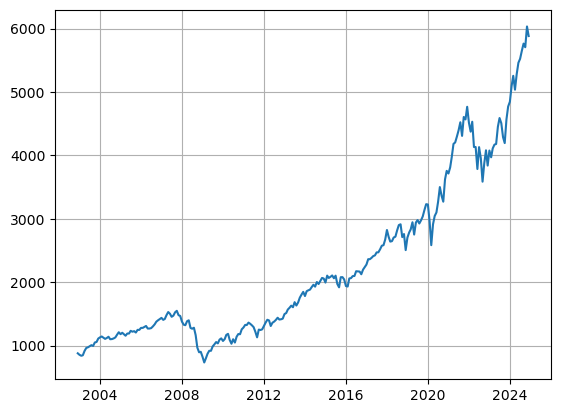

In [29]:
plt.plot(data['year_month'], data['Index'])
plt.grid()

In [34]:
data = data.sort_values('year_month')

In [35]:
data['index_return'] = data['Index'].pct_change()
data['target'] = data['index_return'] - data['Rfree']

In [36]:
# data['log_index'] = np.log(data['Index']).diff() - data['Rfree']
# data[['log_index', 'target']].corr()
# it's the same

In [37]:
data.head()

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target
0,200212,879.82,16.074000,27.59,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.0507,0.0361,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN
1,200301,855.70,16.124000,28.50,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.0106,0.0021,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415
2,200302,841.15,16.174000,29.41,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.0329,0.0264,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904
3,200303,848.18,16.224000,30.32,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.0135,-0.0080,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358
4,200304,916.92,16.204333,31.73,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.0102,0.0229,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044


In [38]:
data = data.merge(normalized_df, on='year_month', how='left')

In [39]:
data

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target,msi_ma_4m_norm,negative_growth_llama_ma_4m_norm,positive_growth_llama_ma_4m_norm,polarity_growth_llama_ma_4m_norm
0,200212,879.82,16.074000,27.590000,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.050700,0.036100,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN,NaN,NaN,NaN,NaN
1,200301,855.70,16.124000,28.500000,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.010600,0.002100,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415,NaN,NaN,NaN,NaN
2,200302,841.15,16.174000,29.410000,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.032900,0.026400,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904,NaN,NaN,NaN,NaN
3,200303,848.18,16.224000,30.320000,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.013500,-0.008000,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358,NaN,NaN,NaN,NaN
4,200304,916.92,16.204333,31.730000,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.010200,0.022900,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044,-3.584048,1.521774,-0.073261,-0.58452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898,2024-08-01,0.022835,0.018035,NaN,NaN,NaN,NaN
261,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707,2024-09-01,0.020197,0.016197,NaN,NaN,NaN,NaN
262,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523,2024-10-01,-0.009897,-0.013797,NaN,NaN,NaN,NaN
263,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016,2024-11-01,0.057301,0.053301,NaN,NaN,NaN,NaN


### Control variables

we use 14 monthly economic variables that are linked directly to macroeconomic fundamentals, which are 
- the log dividend-price ratio (DP): log of a 12-month moving sum of dividends paid on the S&P 500 index minus the log of stock prices (S&P 500 index) 
- log dividend yield (DY): difference between the log of dividends and the log of lagged prices
- log earnings-price ratio (EP): difference between the log of earnings on the S&P 500 index and the log of prices, where earnings is measured using a one-year moving sum 
- log dividend-payout ratio (DE): difference between the log of dividends and the log of earnings on the S&P 500 index
- stock return variance (SVAR),
- book-to-market ratio (BM),
- net equity expansion (NTIS),
- Treasury bill rate (TBL), 
- long-term bond yield (LTY),
- long-term bond return (LTR), 
- term spread (TMS): difference between the long-term yield and the Treasury bill rate
- default yield spread (DFY): difference between BAA- and AAA-rated corporate bond yields
- default return spread (DFR): difference between the long-term corporate bond return and the long-term government bond return.
- inflation rate (INFL).

In [40]:
data['log_DP'] = np.log(data['D12']) - np.log(data['Index'])

data['lag_Index'] = data['Index'].shift(1)
data['log_DY'] = np.log(data['D12']) - np.log(data['lag_Index'])

data['log_EP'] = np.log(data['E12']) - np.log(data['Index'])
data['log_DE'] = np.log(data['D12']) - np.log(data['E12'])
data['tms'] = data['lty'] - data['tbl']
data['dfy'] = data['BAA'] - data['AAA']
data['dfr'] = data['corpr'] - data['ltr']

In [41]:
data = data.rename(columns={'b/m': 'bm'})

In [42]:
# control_variables = ['log_DP', 'log_DY', 'log_EP', 'log_DE', 'svar', 'b/m', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
control_variables = ['log_DP', 'log_EP', 'svar', 'bm', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
len(control_variables)

12

In [43]:
data

,yyyymm,Index,D12,E12,bm,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target,msi_ma_4m_norm,negative_growth_llama_ma_4m_norm,positive_growth_llama_ma_4m_norm,polarity_growth_llama_ma_4m_norm,log_DP,lag_Index,log_DY,log_EP,log_DE,tms,dfy,dfr
0,200212,879.82,16.074000,27.590000,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.050700,0.036100,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN,NaN,NaN,NaN,NaN,-4.002514,NaN,NaN,-3.462264,-0.540250,0.0365,0.0124,-0.014600
1,200301,855.70,16.124000,28.500000,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.010600,0.002100,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415,NaN,NaN,NaN,NaN,-3.971611,879.82,-3.999408,-3.402016,-0.569595,0.0378,0.0118,0.012700
2,200302,841.15,16.174000,29.410000,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.032900,0.026400,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904,NaN,NaN,NaN,NaN,-3.951365,855.70,-3.968515,-3.353435,-0.597930,0.0355,0.0111,-0.006500
3,200303,848.18,16.224000,30.320000,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.013500,-0.008000,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358,NaN,NaN,NaN,NaN,-3.956601,841.15,-3.948278,-3.331285,-0.625316,0.0373,0.0106,0.005500
4,200304,916.92,16.204333,31.730000,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.010200,0.022900,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044,-3.584048,1.521774,-0.073261,-0.58452,-4.035742,848.18,-3.957814,-3.363758,-0.671984,0.0368,0.0111,0.012700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898,2024-08-01,0.022835,0.018035,NaN,NaN,NaN,NaN,-4.349690,5522.30,-4.327112,-3.346711,-1.002979,-0.0118,0.0073,0.002934
261,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707,2024-09-01,0.020197,0.016197,NaN,NaN,NaN,NaN,-4.363195,5648.40,-4.343200,-3.359457,-1.003738,-0.0100,0.0074,0.005707
262,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523,2024-10-01,-0.009897,-0.013797,NaN,NaN,NaN,NaN,-4.346767,5762.48,-4.356713,-3.333167,-1.013600,-0.0041,0.0068,-0.000460
263,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016,2024-11-01,0.057301,0.053301,NaN,NaN,NaN,NaN,-4.396047,5705.45,-4.340327,-3.372806,-1.023241,-0.0006,0.0064,0.005605


In [44]:
data[control_variables].describe()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
count,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000
mean,-3.989553,-3.122190,0.002939,0.284885,-0.006511,0.015557,0.034194,0.004385,0.018636,0.010253,0.000647,0.002102
std,0.172141,0.353958,0.006649,0.059840,0.016852,0.017921,0.012188,0.030807,0.015737,0.004121,0.019313,0.003945
min,-4.396047,-4.836478,0.000150,0.173410,-0.055954,0.000100,0.006200,-0.112400,-0.015700,0.005500,-0.097600,-0.019153
25%,-4.074094,-3.201425,0.000746,0.238168,-0.017425,0.000900,0.025800,-0.015330,0.005800,0.007900,-0.006600,-0.000354
50%,-3.973667,-3.086025,0.001363,0.286118,-0.008504,0.009000,0.034900,0.002438,0.019200,0.009300,0.000700,0.002017
75%,-3.899373,-2.911181,0.002705,0.330671,0.007936,0.023900,0.044900,0.023000,0.032300,0.011300,0.008000,0.004741
max,-3.281006,-2.565551,0.073153,0.446141,0.028289,0.053400,0.054200,0.144300,0.045300,0.033800,0.073700,0.013736


In [45]:
data[control_variables].corr()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
log_DP,1.000000,-0.270335,0.389299,0.755450,-0.401352,-0.420511,-0.045138,0.117388,0.443922,0.724724,-0.039346,-0.287781
log_EP,-0.270335,1.000000,-0.184919,0.049014,0.249237,0.108182,0.068357,0.070199,-0.070259,-0.527193,-0.219181,-0.000252
svar,0.389299,-0.184919,1.000000,0.156341,-0.238764,-0.129036,-0.062083,0.205030,0.098866,0.512920,-0.366515,-0.284670
bm,0.755450,0.049014,0.156341,1.000000,0.109420,-0.470258,0.118737,0.107927,0.627488,0.426404,-0.008101,-0.200219
ntis,-0.401352,0.249237,-0.238764,0.109420,1.000000,-0.231569,0.103314,0.017893,0.343724,-0.451915,0.039535,0.117523
tbl,-0.420511,0.108182,-0.129036,-0.470258,-0.231569,1.000000,0.508336,-0.005418,-0.745119,-0.188836,-0.037914,0.064805
lty,-0.045138,0.068357,-0.062083,0.118737,0.103314,0.508336,1.000000,-0.049977,0.195563,0.042768,-0.019754,0.022932
ltr,0.117388,0.070199,0.205030,0.107927,0.017893,-0.005418,-0.049977,1.000000,-0.032535,0.069529,-0.396099,-0.265620
tms,0.443922,-0.070259,0.098866,0.627488,0.343724,-0.745119,0.195563,-0.032535,1.000000,0.248170,0.027878,-0.056040
dfy,0.724724,-0.527193,0.512920,0.426404,-0.451915,-0.188836,0.042768,0.069529,0.248170,1.000000,0.093000,-0.267343


## Table 2

In [46]:
target = 'target'

In [47]:
data[f'index_return'] = data['Index'].pct_change(periods=1)
data['index_return'] = (data['index_return'] - data['Rfree'])

data['cum_return'] = (1 + data['index_return']).cumprod()
data['net_cum_return'] = data['cum_return'] - 1

In [48]:
return_names = []

for period in [1, 3, 6, 9, 12, 24, 36]:
    return_names.append(f'net_cum_return{period}')

In [49]:
for i in data.index:
    
    working_data = data.loc[i:i+37].copy()
    working_data['net_cum_return'] = (1 + working_data['index_return']).cumprod() - 1

    for period in [1, 3, 6, 9, 12, 24, 36]:

        working_data[f'net_cum_return{period}'] = working_data['net_cum_return'].shift(periods=-period)
    
    data.loc[i, return_names] = working_data[return_names].iloc[0]

In [50]:
# data[return_names] = data[return_names] * 100

In [51]:
data = data.merge(df, on='year_month', how='left')

In [60]:
for sentiment in ['msi', 'polarity_growth_MB', 'polarity_growth_llama', 'negative_growth_llama', 'positive_growth_llama']:

    ss = StandardScaler()
    data[f"{sentiment}_norm"] = ss.fit_transform(data[[sentiment]])

In [53]:
[col for col in data.columns if 'msi' in col]

['msi_ma_4m_norm', 'msi', 'msi_ma_4m', 'msi_norm']

In [54]:
[col for col in data.columns if 'polarity_growth_MB' in col]

['polarity_growth_MB', 'polarity_growth_MB_ma_4m', 'polarity_growth_MB_norm']

In [55]:
res = ols_new_west(data, x_vars=['msi_norm'], target='net_cum_return1')
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:        net_cum_return1   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     4.224
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0413
Time:                        15:43:51   Log-Likelihood:                 263.80
No. Observations:                 180   AIC:                            -523.6
Df Residuals:                     178   BIC:                            -517.2
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0127      0.006      2.240      0.0

In [62]:
data_ = data[data['yyyymm'].between(200301, 201412)].copy().reset_index(drop=True)

In [83]:
features_res, table_res = fit_one_factor(data_, 'msi_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.018**,-2.403,9.079,0.016
net_cum_return3,-0.035***,-2.689,15.392,0.007
net_cum_return6,-0.049***,-2.577,15.59,0.01
net_cum_return9,-0.063***,-2.815,17.681,0.005
net_cum_return12,-0.065***,-2.567,14.847,0.01
net_cum_return24,-0.074*,-1.949,8.831,0.051
net_cum_return36,-0.081**,-2.037,6.883,0.042


In [97]:
features_res, table_res = fit_one_factor(data_, 'polarity_growth_MB_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,0.02***,2.797,37.288,0.005
net_cum_return3,0.015,1.549,45.679,0.121
net_cum_return6,0.022,1.548,59.36,0.122
net_cum_return9,0.038***,2.876,66.101,0.004
net_cum_return12,0.032***,2.77,66.827,0.006
net_cum_return24,0.031**,1.991,77.127,0.046
net_cum_return36,0.023,1.343,88.58,0.179


In [87]:
features_res, table_res = fit_one_factor(data_, 'polarity_growth_llama_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.012***,-2.563,3.471,0.01
net_cum_return3,-0.025***,-2.766,7.431,0.006
net_cum_return6,-0.046***,-2.92,12.895,0.004
net_cum_return9,-0.065***,-2.944,17.765,0.003
net_cum_return12,-0.085***,-3.154,25.127,0.002
net_cum_return24,-0.154***,-3.834,38.639,0.0
net_cum_return36,-0.211***,-5.617,48.979,0.0


In [63]:
features_res, table_res = fit_one_factor(data_, 'negative_growth_llama_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,0.014**,2.372,3.03,0.018
net_cum_return3,0.025**,2.203,4.612,0.028
net_cum_return6,0.043**,2.258,7.313,0.024
net_cum_return9,0.058**,2.308,9.121,0.021
net_cum_return12,0.073**,2.413,11.898,0.016
net_cum_return24,0.115**,2.023,13.869,0.043
net_cum_return36,0.141**,2.032,13.994,0.042


In [64]:
features_res, table_res = fit_one_factor(data_, 'positive_growth_llama_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.01**,-2.34,2.446,0.019
net_cum_return3,-0.023***,-2.77,6.619,0.006
net_cum_return6,-0.042***,-2.953,12.157,0.003
net_cum_return9,-0.061***,-2.92,17.577,0.004
net_cum_return12,-0.082***,-3.103,25.8,0.002
net_cum_return24,-0.156***,-3.995,43.954,0.0
net_cum_return36,-0.221***,-6.95,59.761,0.0


In [67]:
res_ = ols_new_west(data_, x_vars=['negative_growth_llama_norm', 'positive_growth_llama_norm'], target='net_cum_return1')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:        net_cum_return1   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     3.414
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0357
Time:                        15:47:02   Log-Likelihood:                 200.37
No. Observations:                 144   AIC:                            -394.7
Df Residuals:                     141   BIC:                            -385.8
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [101]:
vix = pd.read_csv('VIX_History.csv')

In [103]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9147 entries, 0 to 9146
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    9147 non-null   object 
 1   OPEN    9147 non-null   float64
 2   HIGH    9147 non-null   float64
 3   LOW     9147 non-null   float64
 4   CLOSE   9147 non-null   float64
dtypes: float64(4), object(1)
memory usage: 357.4+ KB


In [116]:
vix['DATE'] = pd.to_datetime(vix['DATE'])
vix['year_month'] = vix['DATE'].astype(str).str[:7]

In [129]:
ss = StandardScaler()
vix['close_norm'] = ss.fit_transform(vix[['CLOSE']])

In [194]:
vix.describe(percentiles=[0.1, 0.9]).round(2)

,DATE,OPEN,HIGH,LOW,CLOSE,close_norm
count,9147,9147.00,9147.00,9147.00,9147.00,9147.00
mean,2008-02-22 18:03:53.781567744,19.54,20.38,18.77,19.45,-0.00
min,1990-01-02 00:00:00,2.58,9.31,8.56,9.14,-1.33
10%,1993-08-14 19:12:00,12.16,12.67,11.75,12.14,-0.94
50%,2008-02-27 00:00:00,17.66,18.34,16.99,17.60,-0.24
90%,2022-09-01 09:36:00,28.75,29.90,27.57,28.58,1.18
max,2026-03-20 00:00:00,82.69,89.53,72.76,82.69,8.15
std,NaN,7.84,8.32,7.29,7.76,1.00


In [214]:
q10 = np.percentile(vix['close_norm'], q=10).item()
q50 = np.percentile(vix['close_norm'], q=50).item()
q90 = np.percentile(vix['close_norm'], q=90).item()
q10, q50, q90

(-0.9417773691588096, -0.23826725041499208, 1.1764838674983986)

In [149]:
vix_df = vix.groupby('year_month').agg(
    {'close_norm': 'mean',}
)
vix_df.columns = ['vix_norm']

vix_df = vix_df.reset_index()
vix_df['year_month'] = pd.to_datetime(vix_df['year_month'])

In [151]:
vix_df.tail()

,year_month,vix_norm
430,2025-11-01,0.041269
431,2025-12-01,-0.502640
432,2026-01-01,-0.421354
433,2026-02-01,-0.031209
434,2026-03-01,0.675265


In [152]:
data_v = data.merge(vix_df, on='year_month', how='left')

In [153]:
data_v['sent_vix'] = data_v['polarity_growth_llama_norm'] * data_v['vix_norm']

In [156]:
features_res, table_res = fit_one_factor(data_v, 'polarity_growth_llama_norm', return_names, ['vix_norm', 'sent_vix'])
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.016***,-4.226,12.125,0.0
net_cum_return3,-0.026***,-4.627,14.904,0.0
net_cum_return6,-0.038***,-4.03,17.77,0.0
net_cum_return9,-0.051***,-3.665,21.686,0.0
net_cum_return12,-0.068***,-3.533,26.028,0.0
net_cum_return24,-0.102***,-3.263,26.296,0.001
net_cum_return36,-0.133***,-3.447,33.155,0.001


In [195]:
res_v = ols_new_west(data_v, x_vars=['polarity_growth_llama_norm', 'vix_norm', 'sent_vix'], target='net_cum_return12')
print(res_v.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return12   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     7.629
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           6.72e-05
Time:                        14:30:08   Log-Likelihood:                 141.69
No. Observations:                 252   AIC:                            -275.4
Df Residuals:                     248   BIC:                            -261.3
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [202]:
data_v[['net_cum_return12', 'polarity_growth_llama_norm', 'vix_norm', 'sent_vix']]
# .info()

,net_cum_return12,polarity_growth_llama_norm,vix_norm,sent_vix
0,0.251209,NaN,1.128871,NaN
1,0.271949,-0.809592,1.027572,-0.831914
2,0.324346,-0.272748,1.645287,-0.448748
3,0.325216,-0.407467,1.441174,-0.587231
4,0.292395,-0.711201,0.585317,-0.416278
...,...,...,...,...
260,NaN,NaN,-0.017644,NaN
261,NaN,NaN,-0.230107,NaN
262,NaN,NaN,0.065926,NaN
263,NaN,NaN,-0.442461,NaN


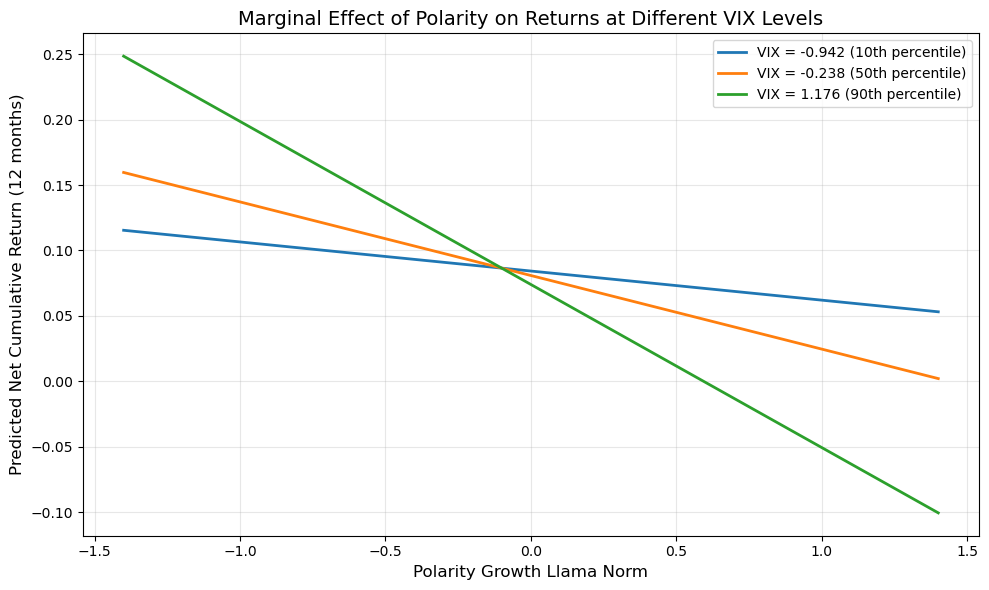

In [215]:
q10 = np.percentile(vix['close_norm'], q=10).item()
q50 = np.percentile(vix['close_norm'], q=50).item()
q90 = np.percentile(vix['close_norm'], q=90).item()

polarity_values = np.linspace(-1.4, 1.4, 100)
 

data_q10 = pd.DataFrame({
    'polarity_growth_llama_norm': polarity_values,
    'vix_norm': q10,
    'sent_vix': polarity_values * q10
})

# Вариант 2: vix_norm = q50
data_q50 = pd.DataFrame({
    'polarity_growth_llama_norm': polarity_values,
    'vix_norm': q50,
    'sent_vix': polarity_values * q50
})

# Вариант 3: vix_norm = q90
data_q90 = pd.DataFrame({
    'polarity_growth_llama_norm': polarity_values,
    'vix_norm': q90,
    'sent_vix': polarity_values * q90
})

# Получаем предсказания
pred_q10 = res_v.predict(data_q10)
pred_q50 = res_v.predict(data_q50)
pred_q90 = res_v.predict(data_q90)

# Строим график
plt.figure(figsize=(10, 6))

plt.plot(polarity_values, pred_q10, label=f'VIX = {q10:.3f} (10th percentile)', linewidth=2)
plt.plot(polarity_values, pred_q50, label=f'VIX = {q50:.3f} (50th percentile)', linewidth=2)
plt.plot(polarity_values, pred_q90, label=f'VIX = {q90:.3f} (90th percentile)', linewidth=2)

plt.xlabel('Polarity Growth Llama Norm', fontsize=12)
plt.ylabel('Predicted Net Cumulative Return (12 months)', fontsize=12)
plt.title('Marginal Effect of Polarity on Returns at Different VIX Levels', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Recession

In [218]:
rec = pd.read_excel('SENTIMENT.xlsx')

In [221]:
rec = rec[['yearmo', 'recess']]

In [222]:
rec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   yearmo  792 non-null    int64
 1   recess  792 non-null    int64
dtypes: int64(2)
memory usage: 12.5 KB


In [226]:
rec['year_month'] = pd.to_datetime(rec['yearmo'], format='%Y%m')

In [227]:
rec

,yearmo,recess,year_month
0,195801,1,1958-01-01
1,195802,1,1958-02-01
2,195803,1,1958-03-01
3,195804,1,1958-04-01
4,195805,0,1958-05-01
...,...,...,...
787,202308,0,2023-08-01
788,202309,0,2023-09-01
789,202310,0,2023-10-01
790,202311,0,2023-11-01


In [228]:
data_r = data.merge(rec, on='year_month', how='left')

In [230]:
data_r['sent_rec'] = data_r['polarity_growth_llama_norm'] * data_r['recess']

In [231]:
features_res, table_res = fit_one_factor(data_r, 'polarity_growth_llama_norm', return_names, ['recess', 'sent_rec'])
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.007***,-2.61,16.36,0.009
net_cum_return3,-0.014***,-3.174,19.816,0.002
net_cum_return6,-0.022***,-2.996,25.926,0.003
net_cum_return9,-0.031***,-3.092,30.855,0.002
net_cum_return12,-0.048***,-3.522,30.892,0.0
net_cum_return24,-0.091***,-2.609,26.502,0.009
net_cum_return36,-0.137***,-2.805,31.124,0.005


In [232]:
res_r = ols_new_west(data_r, x_vars=['polarity_growth_llama_norm', 'recess', 'sent_rec'], target='net_cum_return1')
print(res_r.summary())

                            OLS Regression Results                            
Dep. Variable:        net_cum_return1   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     7.106
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000134
Time:                        14:59:14   Log-Likelihood:                 373.18
No. Observations:                 252   AIC:                            -738.4
Df Residuals:                     248   BIC:                            -724.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           